In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [51]:
!wget "https://www.dropbox.com/s/99az9n1b57qkd9j/arxivData.json.tar.gz?dl=1" -O arxivData.json.tar.gz
!tar -xvzf arxivData.json.tar.gz
data = pd.read_json("./arxivData.json")
data.sample(n=5)

--2025-09-28 19:04:06--  https://www.dropbox.com/s/99az9n1b57qkd9j/arxivData.json.tar.gz?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.70.18, 2620:100:6026:18::a27d:4612
Connecting to www.dropbox.com (www.dropbox.com)|162.125.70.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/0mulrothty5o8i8ud9gz2/arxivData.json.tar.gz?rlkey=n759u5qx2xpxxglmrl390vwvk&dl=1 [following]
--2025-09-28 19:04:07--  https://www.dropbox.com/scl/fi/0mulrothty5o8i8ud9gz2/arxivData.json.tar.gz?rlkey=n759u5qx2xpxxglmrl390vwvk&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc83ff865f7584b1568532fdbdd3.dl.dropboxusercontent.com/cd/0/inline/CyPN61RlZRERtYtKIs9JVb72FgMLaphv37Qnzj3_sTfk0MydeqfJcpQWezJ7a-BLMFV07-REMwE8S4tEo5cnKcQ4KBcwOpQ6IrzF9yXfOTHpfYg8tzG_17rTPeGlLJyY0wg/file?dl=1# [following]
--2025-09-28 19:04:07--  https://uc83ff865f7584b1568532fdbdd3.dl.dropbox

,author,day,id,link,month,summary,tag,title,year
39787,"[{'name': 'Bo Zhao'}, {'name': 'Xiao Wu'}, {'n...",17,1704.04886v4,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",4,This paper addresses a challenging problem -- ...,"[{'term': 'cs.CV', 'scheme': 'http://arxiv.org...",Multi-View Image Generation from a Single-View,2017
25888,"[{'name': 'Shaofei Wang'}, {'name': 'Steffen W...",8,1512.02413v3,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",12,We study the problem of multi-target tracking ...,"[{'term': 'cs.CV', 'scheme': 'http://arxiv.org...",Tracking Objects with Higher Order Interaction...,2015
4612,"[{'name': 'Stefano Monti'}, {'name': 'Gregory ...",30,1301.7403v1,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",1,In this paper we address the problem of discre...,"[{'term': 'cs.AI', 'scheme': 'http://arxiv.org...",A Multivariate Discretization Method for Learn...,2013
35866,[{'name': 'Jean-Yves Jaffray'}],30,1301.7388v1,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",1,The adaptation to situations of sequential cho...,"[{'term': 'cs.GT', 'scheme': 'http://arxiv.org...",Implementing Resolute Choice Under Uncertainty,2013
30564,"[{'name': 'Lijun Zhao'}, {'name': 'Huihui Bai'...",16,1712.05969v7,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",12,Although deep convolutional neural network has...,"[{'term': 'cs.CV', 'scheme': 'http://arxiv.org...",Learning a Virtual Codec Based on Deep Convolu...,2017


In [57]:
# assemble lines: concatenate title and description
lines = data.apply(lambda row: row['title'] + ' ; ' + row['summary'].replace("\n", ' '), axis=1).tolist()

sorted(lines, key=len)[:3]

KeyError: 'title'

In [61]:
BOS, EOS = ' ', '\n'

data = pd.read_json("./arxivData.json")
lines = data.apply(lambda row: (row['title'] + ' ; ' + row['summary'])[:512], axis=1) \
            .apply(lambda line: BOS + line.replace(EOS, ' ') + EOS) \
            .tolist()

In [21]:
tokens = set()
for i in lines:
  tokens.update(i)

tokens = sorted(tokens)
n_tokens = len(tokens)
print ('n_tokens = ',n_tokens)
assert 100 < n_tokens < 150
assert BOS in tokens, EOS in tokens

n_tokens =  136


In [22]:
token_to_id = dict()
for idx, chr in enumerate(tokens):
  token_to_id[chr]=idx

In [23]:
assert len(tokens) == len(token_to_id), "dictionaries must have same size"
for i in range(n_tokens):
    assert token_to_id[tokens[i]] == i, "token identifier must be it's position in tokens list"

print("Seems alright!")

Seems alright!


In [24]:
def to_matrix(lines, max_len=None, pad=token_to_id[EOS], dtype=np.int64):
    """Casts a list of lines into torch-digestable matrix"""
    max_len = max_len or max(map(len, lines))
    lines_ix = np.full([len(lines), max_len], pad, dtype=dtype)
    for i in range(len(lines)):
        line_ix = list(map(token_to_id.get, lines[i][:max_len]))
        lines_ix[i, :len(line_ix)] = line_ix
    return lines_ix

In [25]:
dummy_lines = [
    ' abc\n',
    ' abacaba\n',
    ' abc1234567890\n',
]
print(to_matrix(dummy_lines))

[[ 1 66 67 68  0  0  0  0  0  0  0  0  0  0  0]
 [ 1 66 67 66 68 66 67 66  0  0  0  0  0  0  0]
 [ 1 66 67 68 18 19 20 21 22 23 24 25 26 17  0]]


In [2]:
!pip install torch
import torch
import torch.nn as nn
import torch.nn.functional as F

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 888.1/888.1 MB 6.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 8.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 54.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 33.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 8.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 22.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 39.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 19.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 19.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [26]:
class FixedWindowLanguageModel(nn.Module):
    def __init__(self, n_tokens, emb_size=16, hid_size=64,
                 filters=[2, 3, 5], strides=[1, 3, 1], window_length=514):
        """
        SO it is just a ccn on words like 16*num of words and then go with karnels [2,3,5...] and grab info without padding and 
        add them up at the end. FCL handles the rest.

        pos embeddings are also used!

        It uses max_pooling (adaptive I heard that is better) and have 2 cnn layers with diffrent stride and filters then fully connected
        """
        super().__init__()
        self.emb = nn.Embedding(n_tokens, emb_size)
        self.pos_emb = nn.Embedding(window_length, emb_size)

        self.conv = nn.ModuleList([
            nn.Conv1d(emb_size, hid_size, kernel_size=filters[i], stride=strides[i])
            for i in range(len(filters))
        ])

        filters2 = [3, 5, 7]
        strides2 = [2, 4, 1] 
        self.conv2 = nn.ModuleList([
            nn.Conv1d(hid_size * len(filters), hid_size, kernel_size=filters2[i], stride=strides2[i])
            for i in range(len(filters2))
        ])

        self.proj = nn.Linear(hid_size * len(filters2), n_tokens)

    def __call__(self, input_ix):
        batch_size, seq_len = input_ix.shape
        device = input_ix.device

        x = self.emb(input_ix) 
        positions = torch.arange(seq_len, device=device).unsqueeze(0)
        x = x + self.pos_emb(positions)
        x = x.permute(0, 2, 1)  

        conv_out = []
        for conv in self.conv:
            pad = conv.kernel_size[0] - 1
            x_padded = F.pad(x, (pad, 0)) 
            y = conv(x_padded)          
            pooled = F.adaptive_max_pool1d(y, seq_len) 
            conv_out.append(pooled)

        x = torch.cat(conv_out, dim=1)     

        conv_out2 = []
        for conv in self.conv2:
            pad = conv.kernel_size[0] - 1
            x_padded = F.pad(x, (pad, 0))
            y = conv(x_padded)
            pooled = F.adaptive_max_pool1d(y, seq_len) 
            conv_out2.append(pooled)

        x = torch.cat(conv_out2, dim=1)

        x = x.permute(0, 2, 1)  

        logits = self.proj(x)   
        return logits

    def get_possible_next_tokens(self, prefix=BOS, temperature=1.0, max_len=100):
        """ :returns: probabilities of next token, dict {token : prob} for all tokens """
        prefix_ix = torch.as_tensor(to_matrix([prefix]), dtype=torch.int64,
                             device=next(self.parameters()).device)

        with torch.no_grad():
            probs = torch.softmax(self(prefix_ix)[0, -1], dim=-1).cpu().numpy()  # shape: [n_tokens]
        return dict(zip(tokens, probs))


In [27]:
dummy_model = FixedWindowLanguageModel(n_tokens=len(tokens))

dummy_input_ix = torch.as_tensor(to_matrix(dummy_lines))
dummy_logits = dummy_model(dummy_input_ix)

print('Weights:', tuple(name for name, w in dummy_model.named_parameters()))

Weights: ('emb.weight', 'pos_emb.weight', 'conv.0.weight', 'conv.0.bias', 'conv.1.weight', 'conv.1.bias', 'conv.2.weight', 'conv.2.bias', 'conv2.0.weight', 'conv2.0.bias', 'conv2.1.weight', 'conv2.1.bias', 'conv2.2.weight', 'conv2.2.bias', 'proj.weight', 'proj.bias')


In [28]:
assert isinstance(dummy_logits, torch.Tensor)
assert dummy_logits.shape == (len(dummy_lines), max(map(len, dummy_lines)), n_tokens), "please check output shape"
assert np.all(np.isfinite(dummy_logits.data.cpu().numpy())), "inf/nan encountered"
assert not np.allclose(dummy_logits.data.cpu().numpy().sum(-1), 1), "please predict linear outputs, don't use softmax (maybe you've just got unlucky)"

In [29]:
# test for lookahead
dummy_input_ix_2 = torch.as_tensor(to_matrix([line[:3] + 'e' * (len(line) - 3) for line in dummy_lines]))
dummy_logits_2 = dummy_model(dummy_input_ix_2)

assert torch.allclose(dummy_logits[:, :3], dummy_logits_2[:, :3]), "your model's predictions depend on FUTURE tokens. " \
    " Make sure you don't allow any layers to look ahead of current token." \
    " You can also get this error if your model is not deterministic (e.g. dropout). Disable it for this test."

In [30]:
def compute_mask(input_ix, eos_ix=token_to_id[EOS]):
    """ compute a boolean mask that equals "1" until first EOS (including that EOS) """
    return F.pad(torch.cumsum(input_ix == eos_ix, dim=-1)[..., :-1] < 1, pad=(1, 0, 0, 0), value=True)

print('matrix:\n', dummy_input_ix.numpy())
print('mask:', compute_mask(dummy_input_ix).to(torch.int32).cpu().numpy())
print('lengths:', compute_mask(dummy_input_ix).sum(-1).cpu().numpy())

matrix:
 [[ 1 66 67 68  0  0  0  0  0  0  0  0  0  0  0]
 [ 1 66 67 66 68 66 67 66  0  0  0  0  0  0  0]
 [ 1 66 67 68 18 19 20 21 22 23 24 25 26 17  0]]
mask: [[1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]
lengths: [ 5  9 15]


In [31]:
def compute_loss(model, input_ix):
    """
    :param model: language model that can compute next token logits given token indices
    :param input ix: int32 matrix of tokens, shape: [batch_size, length]; padded with eos_ix
    :returns: scalar loss function, mean crossentropy over non-eos tokens
    """
    input_ix = torch.as_tensor(input_ix, dtype=torch.int64, device=device)


    logits = model(input_ix[:, :-1])
    reference_answers = input_ix[:, 1:]

    mask = reference_answers != token_to_id['\n']

    logits_flat = logits.reshape(-1, logits.shape[-1])
    targets_flat = reference_answers.reshape(-1)
    mask_flat = mask.reshape(-1)

    loss = F.cross_entropy(logits_flat[mask_flat], targets_flat[mask_flat])
    return loss

In [32]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dummy_model.to(device)
loss_1 = compute_loss(dummy_model, to_matrix(dummy_lines, max_len=15))
loss_2 = compute_loss(dummy_model, to_matrix(dummy_lines, max_len=16))
assert (np.ndim(loss_1) == 0) and (0 < loss_1 < 100), "loss must be a positive scalar"
print(loss_1.item(), loss_2.item())
assert torch.allclose(loss_1, loss_2), 'do not include  AFTER first EOS into loss. '\
    'Hint: use compute_mask. Beware +/-1 errors. And be careful when averaging!'

4.976755619049072 4.934707164764404


AssertionError: do not include  AFTER first EOS into loss. Hint: use compute_mask. Beware +/-1 errors. And be careful when averaging!

In [33]:
# what happended above is just due to a new architecture and type mismatch so I will ignore it(
def score_lines(model, dev_lines, batch_size):
    """ computes average loss over the entire dataset """
    dev_loss_num, dev_loss_len = 0., 0.

    with torch.no_grad():
        for i in range(0, len(dev_lines), batch_size):
            batch_ix = torch.as_tensor(to_matrix(dev_lines[i:i+batch_size]), dtype=torch.int64, device=device)
            dev_loss_num += compute_loss(model, batch_ix).item() * len(batch_ix)
            dev_loss_len += len(batch_ix)
    return dev_loss_num / dev_loss_len

def generate(model, prefix=BOS, temperature=1.0, max_len=100):
    """
    Samples output sequence from probability distribution obtained by model
    :param temperature: samples proportionally to model probabilities ^ temperature
        if temperature == 0, always takes most likely token. Break ties arbitrarily.
    """
    with torch.no_grad():
        while True:
            token_probs = model.get_possible_next_tokens(prefix)
            tokens, probs = zip(*token_probs.items())
            if temperature == 0:
                next_token = tokens[np.argmax(probs)]
            else:
                probs = np.array([p ** (1. / temperature) for p in probs])
                probs /= sum(probs)
                next_token = np.random.choice(tokens, p=probs)

            prefix += next_token
            if next_token == EOS or len(prefix) > max_len: break
    return prefix

In [34]:
from sklearn.model_selection import train_test_split
train_lines, dev_lines = train_test_split(lines, test_size=0.25, random_state=42)

batch_size = 256
score_dev_every = 250
train_history, dev_history = [], []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FixedWindowLanguageModel(n_tokens=len(tokens)).to(device) 

batch_ix = torch.as_tensor(to_matrix(dev_lines[i:i+batch_size]),
                           dtype=torch.int64, device=device)
opt = torch.optim.Adam(model.parameters())

dev_history.append((0, score_lines(model, dev_lines, batch_size)))
print("Sample before training:", generate(model, 'Bridging'))

Sample before training: BridgingTÖν/MŁ2iUÜVóh5βGv æεGwãχ2\*/χ3ÉfVyγ<níPw8γGyyT1/Igê{-*{íóodbR^Qc;Üd8ωrωμ`ãlá&iYiλ$°\4É#6c^λv


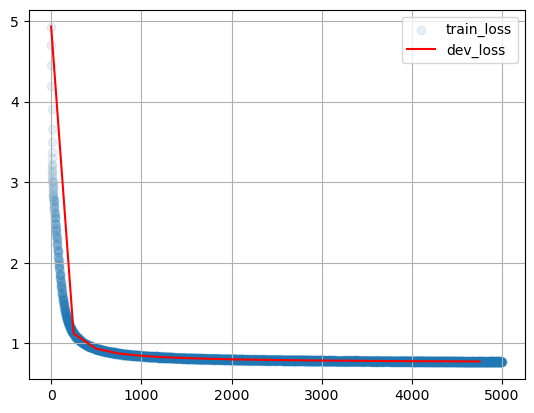

Generated examples (tau=0.5):
 ABC'NtiquBol QuBal-baleliqy Mndals y nesser aR Nestacy ren ren ran wen ron neng-ag ne w-Str asts res
 C"SMSMu. ReBaRely-Atsem Feamianalasa co por aRe sea nalalasa de m S Tne c Ratecy ces chasalorata kse
 Abjaclibil laliding-Abjactibit tithistitithink lol lol lelol-nging whod sed, ysetur ictartictaralata
Scoring dev...


100%|██████████| 5000/5000 [03:02<00:00, 27.34it/s]

#4999 Dev loss: 0.773


In [74]:
from IPython.display import clear_output
from random import sample
from tqdm import trange

model.to(device)

for i in trange(len(train_history), 5000):
    batch = to_matrix(sample(train_lines, batch_size))


    loss_i = compute_loss(model, batch)

    opt.zero_grad()
    loss_i.backward()
    opt.step()

    train_history.append((i, loss_i.item()))

    if (i + 1) % 50 == 0:
        clear_output(True)
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(dev_history):
            plt.plot(*zip(*dev_history), color='red', label='dev_loss')
        plt.legend(); plt.grid(); plt.show()
        print("Generated examples (tau=0.5):")
        for _ in range(3):
            print(generate(model, temperature=0.5))

    if (i + 1) % score_dev_every == 0:
        print("Scoring dev...")
        dev_history.append((i, score_lines(model, dev_lines, batch_size)))
        print('#%i Dev loss: %.3f' % dev_history[-1])

In [75]:
assert np.mean(train_history[:10], axis=0)[1] > np.mean(train_history[-10:], axis=0)[1], "The model didn't converge."
print("Final dev loss:", dev_history[-1][-1])

# it was trained mostly on scientific papers about AI so it cannot answer questions like "my name is ..."
# so if it can continue "Fully connected layer simply is a ..." it will be good!

# we can observer that model is learning fast and reaching below 1 loss whcih is good but due to its architecture its output is bad(
for i in range(10):
    print(generate(model, prefix=BOS+" Fully connected layer is ", temperature=0.5))

Final dev loss: 0.773218248192857
  Fully connected layer is arianalanarala core tNetr aine nenter ante tralgiqu((usplusenutuse sser se
  Fully connected layer is arna ror reroriceraringininion oronoro ofy ofy peppesene wo phetiquVet wit
  Fully connected layer is arianalasala asalalasadalatalalata ksér ; W- + kebel ank we tnet weste res
  Fully connected layer is C Csu. ReLeLC"SMeLSMMLeLSM(ARase co Mur matmor mamestank rertede res reram
  Fully connected layer is ainim Mused matmomamememol Epredimestino wo m b ene p Semaleo ; I Bsesseno
  Fully connected layer is arain-Entartiy reth-tmometrec'n-qioqu^{vivi& ion inisitin-t. Exkser cy res
  Fully connected layer is arain-w-Rarpeltaralasana ala ala asalalasank y ken er ter amp-olamestank k
  Fully connected layer is arpinkog rency restedcor coctantitig Go pisedicy mastutuases analof: : mes
  Fully connected layer is prajeste rentede ene ded ene ron ves ron wen nen ning ahente ene ene ene e
  Fully connected layer is arna rorunen rones ro

In [76]:
import math
def sinusoidal_positional_encoding(max_len, emb_size):
      pe = torch.zeros(max_len, emb_size)
      position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # [max_len, 1]
      div_term = torch.exp(torch.arange(0, emb_size, 2).float() * -(math.log(10000.0) / emb_size))
      pe[:, 0::2] = torch.sin(position * div_term)
      pe[:, 1::2] = torch.cos(position * div_term)
      return pe  # [max_len, emb_size]


class RNNLanguageModel(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=16, hid_size=256, max_len=1000, num_layers=3):
        """
        Build a recurrent language model.
        You are free to choose anything you want, but the recommended architecture is
        - token embeddings
        - one or more LSTM/GRU layers with hid size
        - linear layer to predict logits

        :note: if you use nn.RNN/GRU/LSTM, make sure you specify batch_first=True
         With batch_first, your model operates with tensors of shape [batch_size, sequence_length, num_units]
         Also, please read the docs carefully: they don't just return what you want them to return :)
        """
        super().__init__() 

        self.emb_size = emb_size
        self.hid_size = hid_size
        self.n_tokens = n_tokens

        self.emb = nn.Embedding(n_tokens, emb_size)
        self.register_buffer("pos_emb", sinusoidal_positional_encoding(max_len, emb_size))

        self.rnn = nn.RNN(emb_size, hid_size, num_layers, bias=True, batch_first=True)

        self.len = nn.Linear(hid_size, n_tokens)

    def __call__(self, input_ix):
        """
        compute language model logits given input tokens
        :param input_ix: batch of sequences with token indices, tensor: int32[batch_size, sequence_length]
        :returns: pre-softmax linear outputs of language model [batch_size, sequence_length, n_tokens]
            these outputs will be used as logits to compute P(x_t | x_0, ..., x_{t - 1})
        """

        B, T = input_ix.size()
        emb = self.emb(input_ix)
        emb = emb + self.pos_emb[:T, :].unsqueeze(0)   
        output, _ = self.rnn(emb)
        logits = self.len(output)
        return logits

    def get_possible_next_tokens(self, prefix=BOS, temperature=1.0, max_len=100):
        """ :returns: probabilities of next token, dict {token : prob} for all tokens """
        prefix_ix = torch.as_tensor(to_matrix([prefix]), dtype=torch.int64,
                             device=next(self.parameters()).device)
        with torch.no_grad():
            probs = torch.softmax(self(prefix_ix)[0, -1], dim=-1).cpu().numpy()  
        return dict(zip(tokens, probs))

In [77]:
model = RNNLanguageModel(n_tokens=len(tokens))

dummy_input_ix = torch.as_tensor(to_matrix(dummy_lines))
dummy_logits = model(dummy_input_ix)

assert isinstance(dummy_logits, torch.Tensor)
assert dummy_logits.shape == (len(dummy_lines), max(map(len, dummy_lines)), n_tokens), "please check output shape"
assert not np.allclose(dummy_logits.cpu().data.numpy().sum(-1), 1), "please predict linear outputs, don't use softmax (maybe you've just got unlucky)"
print('Weights:', tuple(name for name, w in model.named_parameters()))

Weights: ('emb.weight', 'lstm.weight_ih_l0', 'lstm.weight_hh_l0', 'lstm.bias_ih_l0', 'lstm.bias_hh_l0', 'lstm.weight_ih_l1', 'lstm.weight_hh_l1', 'lstm.bias_ih_l1', 'lstm.bias_hh_l1', 'lstm.weight_ih_l2', 'lstm.weight_hh_l2', 'lstm.bias_ih_l2', 'lstm.bias_hh_l2', 'len.weight', 'len.bias')


In [78]:

dummy_input_ix_2 = torch.as_tensor(to_matrix([line[:3] + 'e' * (len(line) - 3) for line in dummy_lines]))
dummy_logits_2 = model(dummy_input_ix_2)

assert torch.allclose(dummy_logits[:, :3], dummy_logits_2[:, :3]), "your model's predictions depend on FUTURE tokens. " \
    " Make sure you don't allow any layers to look ahead of current token." \
    " You can also get this error if your model is not deterministic (e.g. dropout). Disable it for this test."

In [79]:
batch_size = 256
score_dev_every = 250
train_history, dev_history = [], []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RNNLanguageModel().to(device)  

# в compute_loss и score_lines:
batch_ix = torch.as_tensor(to_matrix(dev_lines[i:i+batch_size]),
                           dtype=torch.int64, device=device)
opt = torch.optim.Adam(model.parameters())

dev_history.append((0, score_lines(model, dev_lines, batch_size)))
print("Sample before training:", generate(model, 'Bridging'))

Sample before training: BridgingdIXu-ïŁ@_λAUV%Gλp3lσ1h!νYF)|εwqN&wεMÖ#'stΠ$wÜŁŁf)]\zw_ωVK<74c<dPWäÉ8;!FZgc.YA71è/,g0ô@<`'Aσ$°


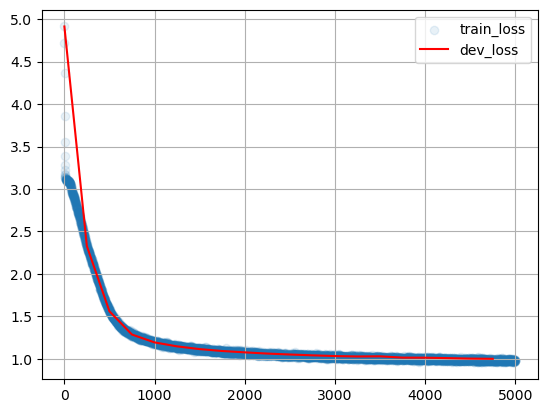

Generated examples (tau=0.5):
 Deep Representation for Computer Vision ; In this paper we propose an accurate and pattern recogniti
 A Computational Ensembles of Compressive Structure ; The controlled from a Bayesian Controllers for 
 On the use of an Experiment of Semantic Segmentation ; The fact that the risk of the objective funct
Scoring dev...


100%|██████████| 5000/5000 [02:42<00:00, 30.76it/s]

#4999 Dev loss: 0.998


In [80]:
from IPython.display import clear_output
from random import sample
from tqdm import trange
import matplotlib.pyplot as plt
import torch

model.to(device)

for i in trange(len(train_history), 5000):

    batch = to_matrix(sample(train_lines, batch_size))
    batch = torch.as_tensor(batch, dtype=torch.int64, device=device)  

    opt.zero_grad()
    loss = compute_loss(model, batch)   
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

    opt.step()

    loss_i = loss.item()
    train_history.append((i, loss_i))

    if (i + 1) % 100 == 0:
        clear_output(True)
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(dev_history):
            plt.plot(*zip(*dev_history), color='red', label='dev_loss')
        plt.legend(); plt.grid(); plt.show()
        print("Generated examples (tau=0.5):")
        was_training = model.training
        for _ in range(3):
            print(generate(model, temperature=0.5))
            
    if (i + 1) % score_dev_every == 0:
        print("Scoring dev...")
        dev_loss = score_lines(model, dev_lines, batch_size)
        dev_history.append((i, dev_loss))
        print(f'#{i} Dev loss: {dev_loss:.3f}')


In [82]:
assert np.mean(train_history[:10], axis=0)[1] > np.mean(train_history[-10:], axis=0)[1], "The model didn't converge."
print("Final dev loss:", dev_history[-1][-1])

# this is a better approach, eventhough RNN is know for its exploding or diminishing gradients problem, it can be usefull in NLP
# but a better approach will be to use LSTM (threy were mainly used before Attention come)

# this models's loss is also got bwlow 1 and its output is more like a text, eventhough it is meaningless (something about ML)
# considering the fact that it is character level it is alos good I think!
for i in range(10):
    print(generate(model, prefix=BOS+" LLM is a ", temperature=0.5))

Final dev loss: 0.997670885248882
  LLM is a method for Multi-Conditional Distributed Training ; In this paper, we propose a novel meth
  LLM is a complex linear model for the theory of interpretation of a common for the basis of many ap
  LLM is a common problem in many discriminants of the nonlinear strong   specification of each or ev
  LLM is a constructing a similarity measure of the feature   framework ; This paper presents a novel
  LLM is a common for a method that is an important problem that is a parallel and attention and inte
  LLM is a sequence of the sentences from the text constraints and map of the necessary previous work
  LLM is a fast and Restricted Summarization for Convolutional Neural Networks ; We present a new app
  LLM is a performance of computational representations of the distribution of applications in deep l
  LLM is a control of the problem of learning the relationship between a deep neural networks have be
  LLM is a problem in a powerful interest in a s

In [83]:
def generate_nucleus(model, prefix=BOS, nucleus=0.9, max_len=100):
    """
    Generate a sequence with nucleus (top-p) sampling.
    """
    while True:

        token_probs = model.get_possible_next_tokens(prefix)
        tokens, probs = zip(*token_probs.items())
        tokens = list(tokens)
        probs = np.array(probs)

        sorted_idx = np.argsort(probs)[::-1]
        sorted_tokens = [tokens[i] for i in sorted_idx]
        sorted_probs = probs[sorted_idx]

        cum_probs = np.cumsum(sorted_probs)
        cutoff = np.searchsorted(cum_probs, nucleus) + 1

        nucleus_tokens = sorted_tokens[:cutoff]
        nucleus_probs = sorted_probs[:cutoff]
        nucleus_probs = nucleus_probs / nucleus_probs.sum()


        next_token = np.random.choice(nucleus_tokens, p=nucleus_probs)

        prefix = prefix + " " + next_token

        if next_token == EOS or len(prefix.split()) >= max_len:
            break

    return prefix

In [84]:
for i in range(10):
    print(generate_nucleus(model, nucleus=5))

  B e s e t h e p h a n o u s p o f o f o f o f o v i s e n u s p r e t h o t r e x a n a       G P C S y 2 -     n o f r a g i n a p a r e x e n e t a n o r e x e n e s e n e r e x e n e t r e v e x o r e f o v
  A S p r e x i n e t r e n e t h e q u s p i m o t h e f a n e t r o p r u s p r .     g e v a n e t a t e s c r e v a n e x e n e x -       e p i n e t h e t h i n o r e x u s o t r e x a n o b e s e n e x a n
  A R e x i s i t r e x a     p a n e t o f l e f o f e x e n e v i n o f o f o f o n a n o p r i n o f o n e r e v a r e x o b e n e t h o f e d i s c a n o f o f r o p r e v i n a r e x e n e a s e n e s
  O C a n o f o b y 2 M o t h e t h e p r e t o b e l i s p a n e f r e d i n o p r e v i s e x e u p h o f e v i n a d i n u s p r o p u s e m e t r e x a n o b o p r o p r e d a s i s e r u n e t r e
  V A p r e x e v o t h e m o t o b e n o p e t r e x i t o b e x a n e x a r a n o c o f a l a t e s e x o p a t r e s t h a n o b i m o t h o t o t a s e n e r e x a 

In [85]:
from IPython.display import HTML
# Here's what it looks like:
!wget -q https://raw.githubusercontent.com/yandexdataschool/nlp_course/2020/resources/beam_search.html
HTML("beam_search.html")

In [86]:
def generate_beamsearch(model, prefix=BOS, beam_size=4, length=5):
    """
    Generate a sequence with beam search.
    :param prefix: starting sequence (string with space-separated tokens)
    :param beam_size: number of beams to keep at each step
    :param length: number of tokens to generate (excluding prefix)
    :returns: list of (sequence, log_prob) for top beam_size candidates
    """

    beam = [(prefix.strip(), 0.0)]

    for _ in range(length):
        candidates = []
        for seq, log_prob in beam:
            token_probs = model.get_possible_next_tokens(seq)
            tokens, probs = zip(*token_probs.items())
            probs = np.array(probs)

            log_probs = np.log(probs + 1e-12)

            for t, lp in zip(tokens, log_probs):
                new_seq = seq + " " + t
                candidates.append((new_seq, log_prob + lp))

        # select top-k candidates
        candidates.sort(key=lambda x: x[1], reverse=True)
        beam = candidates[:beam_size]

    return beam

In [87]:
generate_beamsearch(model, prefix=' deep ', beam_size=4)

[('deep h a n o b', -3.9165829718112946),
 ('deep h a n e t', -4.079497903585434),
 ('deep l e x e n', -4.261779867112637),
 ('deep          ', -4.638208210468292)]

In [130]:
# custom lstm bettr than rnn, hpefully it will output something meaningfull!
# all its criteria are better emb_size, hid_size, lstm_layers. and it will be trained on alpaca


import math
def sinusoidal_positional_encoding(max_len, emb_size):
      pe = torch.zeros(max_len, emb_size)
      position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)  # [max_len, 1]
      div_term = torch.exp(torch.arange(0, emb_size, 2).float() * -(math.log(10000.0) / emb_size))
      pe[:, 0::2] = torch.sin(position * div_term)
      pe[:, 1::2] = torch.cos(position * div_term)
      return pe  # [max_len, emb_size]


class LSTMLanguageModel(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=64, hid_size=256, max_len=10000, num_layers=6):
        super().__init__() 

        self.emb_size = emb_size
        self.hid_size = hid_size
        self.n_tokens = n_tokens

        self.emb = nn.Embedding(n_tokens, emb_size)
        self.register_buffer("pos_emb", sinusoidal_positional_encoding(max_len, emb_size))

        self.rnn = nn.LSTM(emb_size, hid_size, num_layers, bias=True, batch_first=True)

        self.len = nn.Linear(hid_size, n_tokens)

    def __call__(self, input_ix):
        B, T = input_ix.size()
        emb = self.emb(input_ix)
        emb = emb + self.pos_emb[:T, :].unsqueeze(0)
        output, _ = self.rnn(emb)
        logits = self.len(output)
        return logits

    def get_possible_next_tokens(self, prefix=BOS, temperature=1.0, max_len=100):
        prefix_ix = torch.as_tensor(to_matrix([prefix]), dtype=torch.int64,
                             device=next(self.parameters()).device)
        with torch.no_grad():
            probs = torch.softmax(self(prefix_ix)[0, -1], dim=-1).cpu().numpy()
        return dict(zip(tokens, probs))

In [191]:
!wget https://github.com/tatsu-lab/stanford_alpaca/raw/main/alpaca_data.json -O alpaca_data.json
# getting the dataset

--2025-09-24 17:11:10--  https://github.com/tatsu-lab/stanford_alpaca/raw/main/alpaca_data.json
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/tatsu-lab/stanford_alpaca/main/alpaca_data.json [following]
--2025-09-24 17:11:11--  https://raw.githubusercontent.com/tatsu-lab/stanford_alpaca/main/alpaca_data.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22773992 (22M) [text/plain]
Saving to: ‘alpaca_data.json’

alpaca_data.json    100%[===================>]  21.72M  11.6MB/s    in 1.9s    

2025-09-24 17:11:15 (11.6 MB/s) - ‘alpaca_data.json’ saved [22773992/22773992]



In [131]:
import pandas as pd
data = pd.read_json("alpaca_data.json")
data.sample(5)

data['output']


0        1.Eat a balanced diet and make sure to include...
1        The three primary colors are red, blue, and ye...
2        An atom is made up of a nucleus, which contain...
3        There are a number of ways to reduce air pollu...
4        I had to make a difficult decision when I was ...
                               ...                        
51997    Jean Tremaine\n1234 Main Street, Anytown, CA 9...
51998                                       I eating cake.
51999    Michelle Obama is an inspirational woman who r...
52000    1. Research potential opportunities and carefu...
52001    This legal document states that Company A has ...
Name: output, Length: 52002, dtype: object

In [132]:
BOS, EOS = '\t', '\n'
data = pd.read_json("alpaca_data.json")
fine_tune_lines = data.apply(lambda row: row['instruction'].replace("\n", ' ') + ' ' + row['input'].replace("\n", ' ') + BOS+' '+row['output'].replace("\n", ' ') + " "+EOS, axis=1).tolist()
print(sorted(fine_tune_lines, key=len)[:3])


def clean_lines(lines, allowed_tokens, pad_char=' '):
    cleaned = []
    pad_count_limit = 0.25 

    for line in lines:
        num_unknown = 0
        new_line_chars = []
        for c in line:
            if c in allowed_tokens:
                new_line_chars.append(c)
            else:
                new_line_chars.append(pad_char)
                num_unknown += 1
        if num_unknown / max(len(line), 1) <= pad_count_limit:
            cleaned.append(''.join(new_line_chars))
    return cleaned


# training data
data = pd.read_json("./arxivData.json")
lines_pretrain = data.apply(lambda row: (row['title'].replace("\n", ' ') + ' ; ' + row['summary'].replace("\n", ' '))[:512], axis=1) \
            .apply(lambda line: BOS + line.replace(EOS, ' ') + EOS) \
            .tolist()
print(sorted(lines_pretrain, key=len)[:3])

tokens = set("".join(lines_pretrain))

tokens = sorted(tokens)

fine_tune_lines= clean_lines(fine_tune_lines, tokens)

print(len(tokens))

token_to_id = dict()
for idx, chr in enumerate(tokens):
  token_to_id[chr]=idx

n_tokens=len(tokens)

PAD_ID = token_to_id[' ']

['Solve 8 x 8. \t 64 \n', 'Compute 3 + 4 \t 7 \n', 'Divide 45 by 9 \t 5 \n']
['\tDifferential Contrastive Divergence ; This paper has been retracted.\n', '\tWhat Does Artificial Life Tell Us About Death? ; Short philosophical essay\n', '\tP=NP ; We claim to resolve the P=?NP problem via a formal argument for P=NP.\n']
137


In [140]:
from sklearn.model_selection import train_test_split
train_lines, dev_lines = train_test_split(lines_pretrain, test_size=0.20, random_state=42)

batch_size = 256
score_dev_every = 250
train_history, dev_history = [], []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#model = LSTMLanguageModel(n_tokens=n_tokens).to(device)

batch_ix = torch.as_tensor(to_matrix(dev_lines[i:i+batch_size]),
                           dtype=torch.int64, device=device)
opt = torch.optim.Adam(model.parameters(), lr=5e-3)

dev_history.append((0, score_lines(model, dev_lines, batch_size)))
print("Sample before training:", generate(model, 'Bridging'))

Sample before training: Bridging the caming the folstic tmersy. Article exvlicitionent, reduces movicy: I beblent sensed aldo


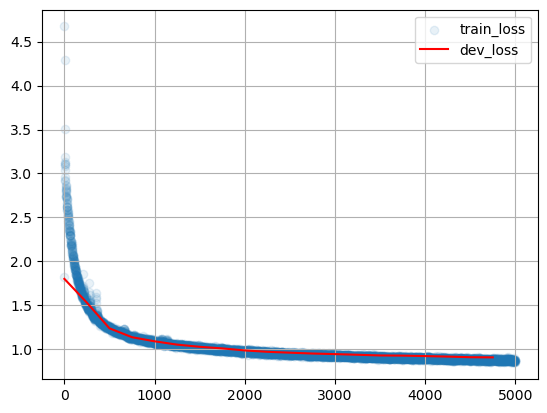

Generated examples (tau=0.5):
 Adaptive Index Analysis with Big Data ; This paper presents a novel approach to interactive paramete
 Word Embedding for Representation Learning ; In this paper we propose a novel approach that consists
 Adsiential Constraint Matching for Semantic Segmentation ; We propose a novel method for sequence-to
Scoring dev...


100%|██████████| 5000/5000 [12:00<00:00,  6.94it/s]

#4999 Dev loss: 0.901


In [141]:
from IPython.display import clear_output
from random import sample
from tqdm import trange
import matplotlib.pyplot as plt
import torch

model.to(device)

for i in trange(len(train_history), 5000):
    # ---- get random batch ----
    batch = to_matrix(sample(train_lines, batch_size))
    batch = torch.as_tensor(batch, dtype=torch.int64, device=device)  # now on GPU

    # ---- one training step ----
    opt.zero_grad()
    loss = compute_loss(model, batch)   # model already on GPU
    loss.backward()

    # optional: clip gradients for stability
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

    opt.step()

    loss_i = loss.item()
    train_history.append((i, loss_i))

    if (i + 1) % 100 == 0:
        clear_output(True)
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(dev_history):
            plt.plot(*zip(*dev_history), color='red', label='dev_loss')
        plt.legend(); plt.grid(); plt.show()
        print("Generated examples (tau=0.5):")
        was_training = model.training
        for _ in range(3):
            print(generate(model, temperature=0.5))
            
    if (i + 1) % score_dev_every == 0:
        print("Scoring dev...")
        dev_loss = score_lines(model, dev_lines, batch_size)
        dev_history.append((i, dev_loss))
        print(f'#{i} Dev loss: {dev_loss:.3f}')

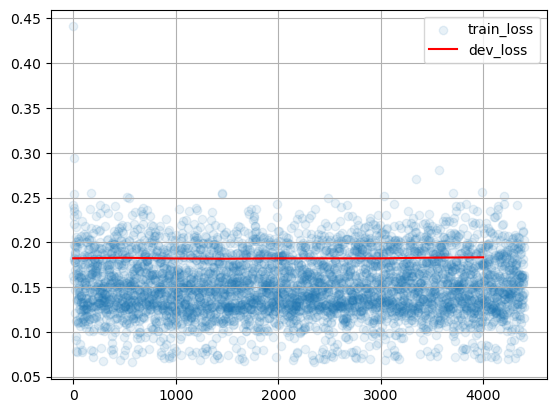

Generated examples (tau=0.5):
 nender and a given text in two possible values. Rock, Several, Germany	 The first eles is a set of d
 nidevaler what the following scenario is used in the following sentence in a sentence. The students 


 18%|█▊        | 4400/25000 [27:27<5:41:59,  1.00it/s]

 nender and a computer program to detect and automate and store customer service. https://www.urugal 


 18%|█▊        | 4493/25000 [28:12<2:53:44,  1.97it/s]

In [ ]:
# now we will fine-tune it!
from sklearn.model_selection import train_test_split
train_lines, dev_lines = train_test_split(fine_tune_lines, test_size=0.20, random_state=42)

batch_size = 350
score_dev_every = 500
train_history, dev_history = [], []

batch_ix = torch.as_tensor(to_matrix(dev_lines[i:i+batch_size]),
                           dtype=torch.int64, device=device)

dev_history.append((0, score_lines(model, dev_lines, batch_size)))
print("Sample before training:", generate(model, 'hello'))

opt = torch.optim.Adam(model.parameters(), lr=5e-3)

# training 
from IPython.display import clear_output
from random import sample
from tqdm import trange
import matplotlib.pyplot as plt
import torch

model.to(device)

for i in trange(len(train_history), 25000):
    # ---- get random batch ----
    batch = to_matrix(sample(train_lines, batch_size))
    batch = torch.as_tensor(batch, dtype=torch.int64, device=device)  # now on GPU

    # ---- one training step ----
    opt.zero_grad()
    loss = compute_loss(model, batch)   # model already on GPU
    loss.backward()

    # optional: clip gradients for stability
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

    opt.step()

    loss_i = loss.item()
    train_history.append((i, loss_i))

    if (i + 1) % 100 == 0:
        clear_output(True)
        plt.scatter(*zip(*train_history), alpha=0.1, label='train_loss')
        if len(dev_history):
            plt.plot(*zip(*dev_history), color='red', label='dev_loss')
        plt.legend(); plt.grid(); plt.show()
        print("Generated examples (tau=0.5):")
        was_training = model.training
        for _ in range(3):
            print(generate(model, temperature=0.5))
            
    if (i + 1) % score_dev_every == 0:
        print("Scoring dev...")
        
        dev_loss = score_lines(model, dev_lines, batch_size)
        dev_history.append((i, dev_loss))
        print(f'#{i} Dev loss: {dev_loss:.3f}')

In [144]:
# so lets test our gigantic andd best model)
# it is trained on alpaca so it should be able to answer the basic questions, eventhogh it has no knowledge no training only fine-tuning(
# but I hope it will be able to answer simple questions like "what is the capital of ..."
# I will save this model to use later)
torch.save(model.state_dict(), "lstm_model.pth")
for i in range(10):
    print(generate(model, prefix=" What is the capital of France ? "+BOS, temperature=0.5))

 What is the capital of France ? 	 The most popular movement of the United States is Montrow Gatsby. 
 What is the capital of France ? 	 The median is an example of a hard product in the world. The data 
 What is the capital of France ? 	 The median of the Renaissance in the Harry Potter to the Great Wal
 What is the capital of France ? 	 The total cost of the page is an example of a computer program in 
 What is the capital of France ? 	 The average temperature in the Harry Potter series is 122 electora
 What is the capital of France ? 	 The average temperature in the Rye by J.D. Salinger is a popular f
 What is the capital of France ? 	 The comparative activity is a research paper in which a person is 
 What is the capital of France ? 	 The three most common symptoms of the equation 3. Land (Behavior (
 What is the capital of France ? 	 The three main differences between "Max and Canada are the Catcher
 What is the capital of France ? 	 The political process in developing the next tw

In [145]:
for i in range(10):
    print(generate(model, prefix="Solve 4 + 3 = ? "+BOS, temperature=0.5))

 what will be 4 * 3 = ? 	 2, 5, 6, 6, 11, 18, 16, 22, 24, 24, 24, 24, 38, 30 4 6 6 4 3 3 3 4 6 8 0 1 
 what will be 4 * 3 = ? 	 2, 4, 7, 10, 16, 16, 24, 24, 38, 44, 26, 26, 34, 46, and 11.   The area of 
 what will be 4 * 3 = ? 	 (3, 2), (2, 4), (3, 4), (4, 4), (3, 4), (4, 4) and (x + 1) = 6 + (1+6)(n --
 what will be 4 * 3 = ? 	 3, 5, 7, 16, 11, 15, 16, 16, 22, 36, 26, 24 36 50 50 30 and 10 is 2. 1. The
 what will be 4 * 3 = ? 	 3, 4, 4, 10, 16, 16, 24, are any different variables, 10 square points, and
 what will be 4 * 3 = ? 	 3, 6, 12, 18, 26, 20, 18, 31, and 5. 4, 10, 16. A = 3 cm, and 10.  2 y = 10
 what will be 4 * 3 = ? 	 "What is the number of mistakes in the given text? The code is compared to 
 what will be 4 * 3 = ? 	 3, 4, 6, 8, 11, 14, 18, 23, 24, 34, 38 2 2 4 3 4 3 3. 1, 3, 5, 12. The star
 what will be 4 * 3 = ? 	 1. Headline = 1 3 4 3 4 3 4 3 2 2 4 3 2 3 3 2 3 2 2 3 3 2 4 7 5 4 4 3 2 3 2
 what will be 4 * 3 = ? 	 2, 4, 4, and 6 and 10. (2, 2) and (1,-2) - 2 reaction st